In [2]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal

In [3]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)

PROCESSED_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed


In [4]:
SEGMENTS = ["pre_meditation", "main_meditation", "recovery"]

VALID_EMOTIBIT_IDS = [
    "EmotiBit_1",
    "EmotiBit_2",
    "EmotiBit_3",
    "EmotiBit_4",
    "EmotiBit_6",
    "EmotiBit_7",
]

CANDIDATE_CLUSTER = ["EmotiBit_4", "EmotiBit_6", "EmotiBit_7"]

# HR aligned at 1-second resolution
FS = 1.0

# Frequency bands to summarize
FREQ_BANDS = {
    "vlf_like_0p01_0p05": (0.01, 0.05),
    "lf_0p05_0p15": (0.05, 0.15),
    "hf_0p15_0p40": (0.15, 0.40),
}

# Welch settings
NPERSEG_BY_SEGMENT = {
    "pre_meditation": 128,
    "main_meditation": 256,
    "recovery": 64,
}

NOVERLAP_RATIO = 0.5

In [5]:
def load_group_hr(segment):
    path = PROCESSED_DIR / f"group_hr_{segment}_aligned_1s.csv"
    if not path.exists():
        return None, path
    return pd.read_csv(path), path


def detrend_series(x):
    x = np.asarray(x, dtype=float)
    return signal.detrend(x, type="linear")


def band_mean(freqs, values, f_low, f_high):
    mask = (freqs >= f_low) & (freqs <= f_high)
    if not np.any(mask):
        return np.nan
    return float(np.nanmean(values[mask]))


def band_power(freqs, psd, f_low, f_high):
    mask = (freqs >= f_low) & (freqs <= f_high)
    if not np.any(mask):
        return np.nan
    return float(np.trapz(psd[mask], freqs[mask]))


def compute_psd(x, fs=1.0, nperseg=256):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 8:
        return np.array([]), np.array([])

    x = detrend_series(x)

    nperseg = min(nperseg, len(x))
    noverlap = int(nperseg * NOVERLAP_RATIO)

    freqs, psd = signal.welch(
        x,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=False,
    )
    return freqs, psd


def compute_coherence(x, y, fs=1.0, nperseg=256):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 8 or len(y) < 8:
        return np.array([]), np.array([])

    x = detrend_series(x)
    y = detrend_series(y)

    nperseg = min(nperseg, len(x), len(y))
    noverlap = int(nperseg * NOVERLAP_RATIO)

    freqs, coh = signal.coherence(
        x,
        y,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=False,
    )
    return freqs, coh

In [6]:
segment_data = {}

for segment in SEGMENTS:
    df, path = load_group_hr(segment)
    if df is None:
        print("Missing:", path)
        continue

    subject_cols = [c for c in VALID_EMOTIBIT_IDS if c in df.columns]
    segment_data[segment] = {
        "df": df.copy(),
        "subject_cols": subject_cols,
    }

    print(segment, df.shape, subject_cols)

pre_meditation (242, 7) ['EmotiBit_1', 'EmotiBit_2', 'EmotiBit_3', 'EmotiBit_4', 'EmotiBit_6', 'EmotiBit_7']
main_meditation (752, 7) ['EmotiBit_1', 'EmotiBit_2', 'EmotiBit_3', 'EmotiBit_4', 'EmotiBit_6', 'EmotiBit_7']
recovery (93, 7) ['EmotiBit_1', 'EmotiBit_2', 'EmotiBit_3', 'EmotiBit_4', 'EmotiBit_6', 'EmotiBit_7']


In [7]:
psd_rows = []
psd_curves = {}

for segment in SEGMENTS:
    if segment not in segment_data:
        continue

    df = segment_data[segment]["df"]
    subject_cols = segment_data[segment]["subject_cols"]
    nperseg = NPERSEG_BY_SEGMENT[segment]

    for subj in subject_cols:
        x = df[subj].values.astype(float)
        freqs, psd = compute_psd(x, fs=FS, nperseg=nperseg)

        psd_curves[(segment, subj)] = (freqs, psd)

        if len(freqs) == 0:
            continue

        row = {
            "segment": segment,
            "subject": subj,
        }

        for band_name, (f_low, f_high) in FREQ_BANDS.items():
            row[f"{band_name}_power"] = band_power(freqs, psd, f_low, f_high)

        psd_rows.append(row)

psd_summary = pd.DataFrame(psd_rows)
display(psd_summary.head(20))

/var/folders/qd/vssg284933g4s6zhb69zzfb80000gn/T/ipykernel_32800/2891356179.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[mask], freqs[mask]))


,segment,subject,vlf_like_0p01_0p05_power,lf_0p05_0p15_power,hf_0p15_0p40_power
0,pre_meditation,EmotiBit_1,6.587903,6.236826,13.543518
1,pre_meditation,EmotiBit_2,0.214566,1.597599,9.691091
2,pre_meditation,EmotiBit_3,0.960865,17.618588,12.679336
3,pre_meditation,EmotiBit_4,3.224868,13.646508,27.339847
4,pre_meditation,EmotiBit_6,17.139677,11.954534,50.331539
5,pre_meditation,EmotiBit_7,3.012580,33.166361,7.581845
6,main_meditation,EmotiBit_1,13.208836,23.923215,48.247714
7,main_meditation,EmotiBit_2,1.533614,1.906397,5.566249
8,main_meditation,EmotiBit_3,3.203275,32.693268,13.644493
9,main_meditation,EmotiBit_4,5.372739,15.658088,6.424156


In [8]:
out_path = TABLES_DIR / "frequency_psd_summary.csv"
psd_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/frequency_psd_summary.csv


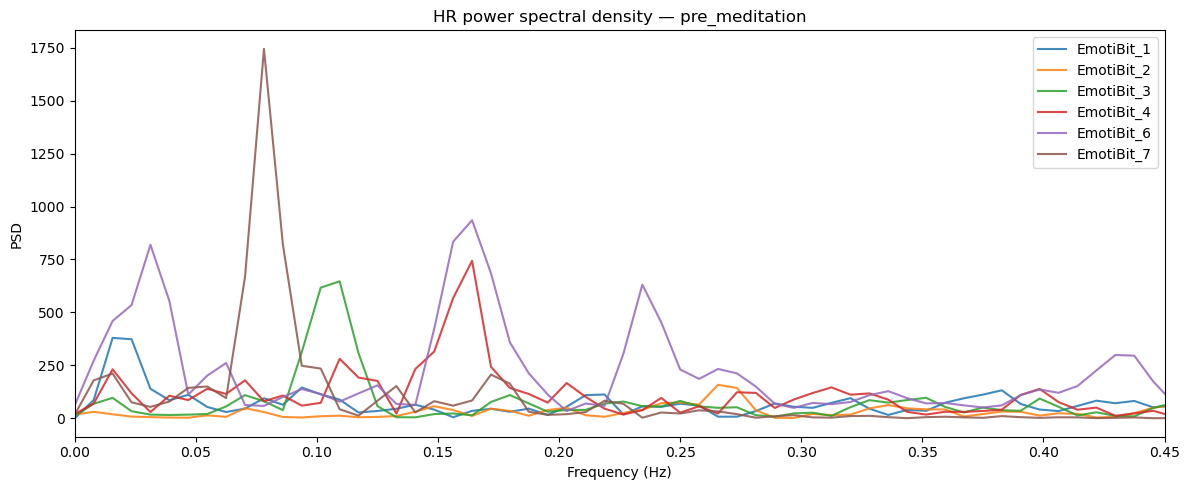

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_psd_pre_meditation.png


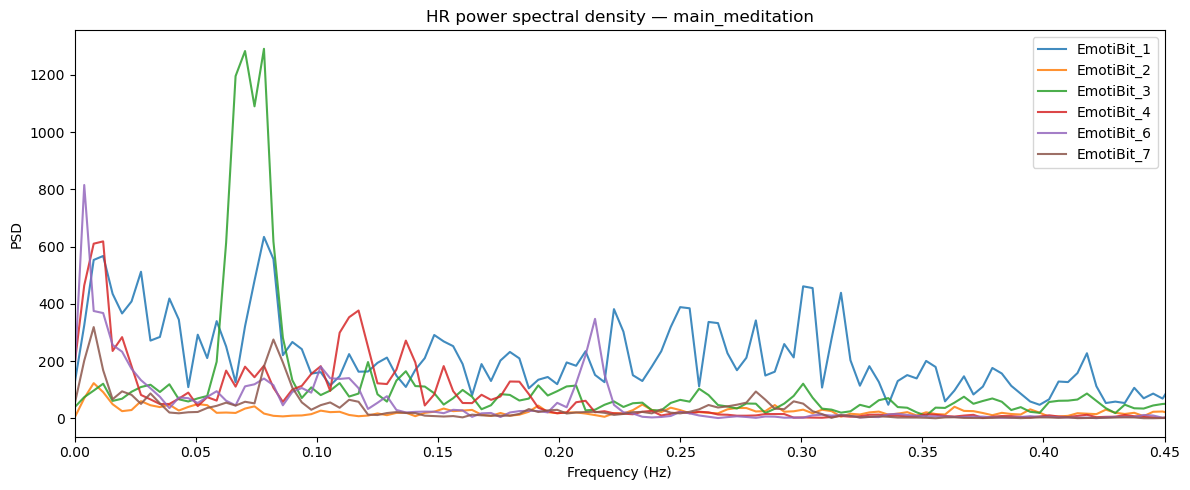

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_psd_main_meditation.png


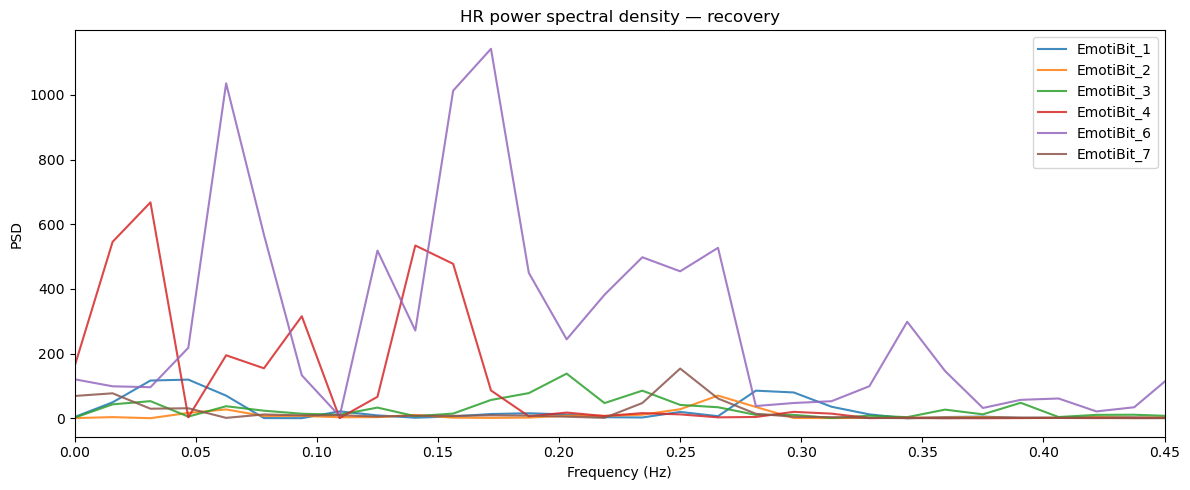

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_psd_recovery.png


In [9]:
for segment in SEGMENTS:
    if segment not in segment_data:
        continue

    plt.figure(figsize=(12, 5))

    for subj in segment_data[segment]["subject_cols"]:
        freqs, psd = psd_curves.get((segment, subj), (None, None))
        if freqs is None or len(freqs) == 0:
            continue
        plt.plot(freqs, psd, label=subj, alpha=0.85)

    plt.xlim(0, 0.45)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title(f"HR power spectral density — {segment}")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"frequency_psd_{segment}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

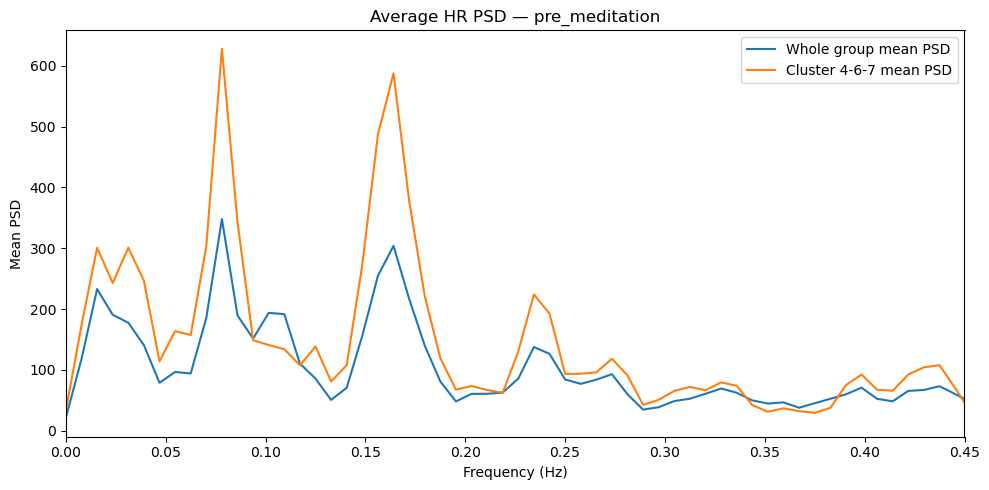

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_avg_psd_pre_meditation.png


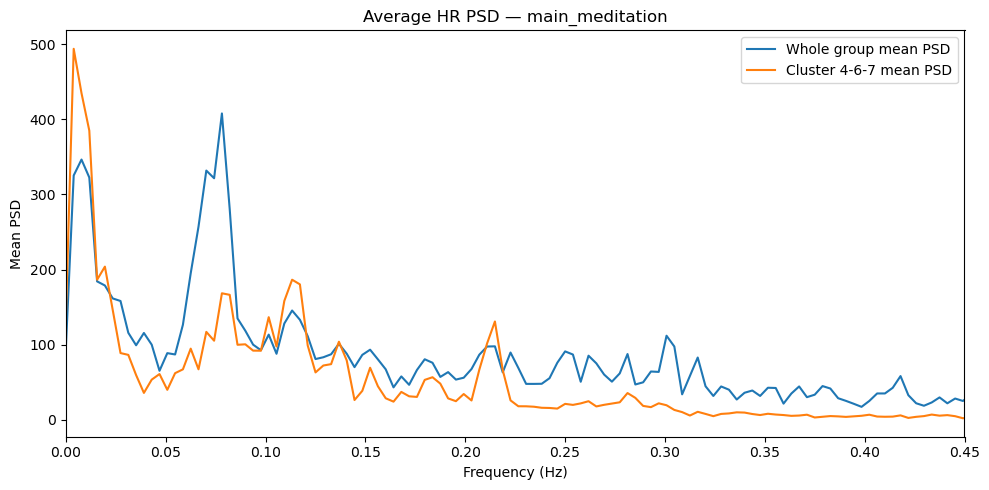

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_avg_psd_main_meditation.png


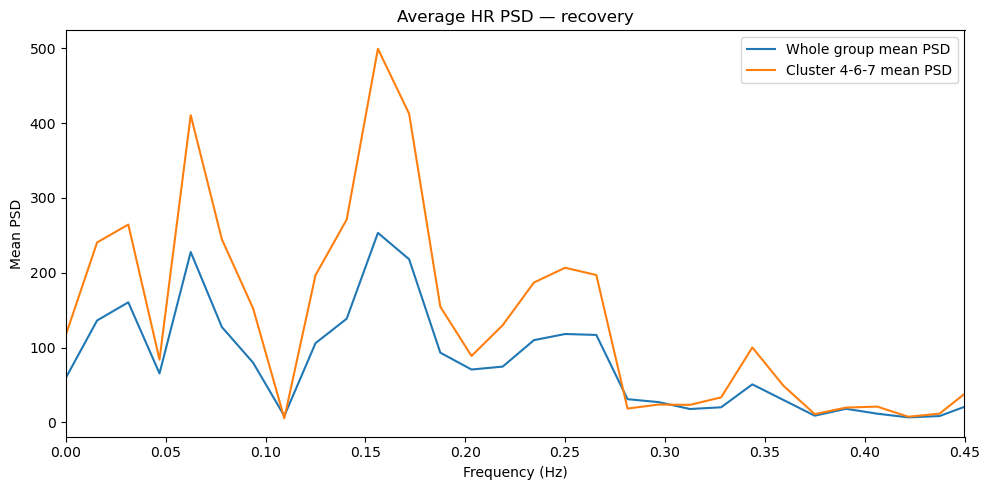

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_avg_psd_recovery.png


In [10]:
for segment in SEGMENTS:
    if segment not in segment_data:
        continue

    subject_cols = segment_data[segment]["subject_cols"]

    all_psd = []
    cluster_psd = []
    freqs_ref = None

    for subj in subject_cols:
        freqs, psd = psd_curves.get((segment, subj), (None, None))
        if freqs is None or len(freqs) == 0:
            continue

        if freqs_ref is None:
            freqs_ref = freqs

        all_psd.append(psd)

        if subj in CANDIDATE_CLUSTER:
            cluster_psd.append(psd)

    if freqs_ref is None or len(all_psd) == 0:
        continue

    all_psd_mean = np.mean(np.vstack(all_psd), axis=0)
    cluster_psd_mean = np.mean(np.vstack(cluster_psd), axis=0) if len(cluster_psd) > 0 else np.full_like(freqs_ref, np.nan)

    plt.figure(figsize=(10, 5))
    plt.plot(freqs_ref, all_psd_mean, label="Whole group mean PSD")
    plt.plot(freqs_ref, cluster_psd_mean, label="Cluster 4-6-7 mean PSD")
    plt.xlim(0, 0.45)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Mean PSD")
    plt.title(f"Average HR PSD — {segment}")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"frequency_avg_psd_{segment}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [11]:
coh_rows = []
coh_curves = {}

for segment in SEGMENTS:
    if segment not in segment_data:
        continue

    df = segment_data[segment]["df"]
    subject_cols = segment_data[segment]["subject_cols"]
    nperseg = NPERSEG_BY_SEGMENT[segment]

    for a, b in itertools.combinations(subject_cols, 2):
        x = df[a].values.astype(float)
        y = df[b].values.astype(float)

        freqs, coh = compute_coherence(x, y, fs=FS, nperseg=nperseg)
        coh_curves[(segment, a, b)] = (freqs, coh)

        if len(freqs) == 0:
            continue

        row = {
            "segment": segment,
            "subject_a": a,
            "subject_b": b,
        }

        for band_name, (f_low, f_high) in FREQ_BANDS.items():
            row[f"{band_name}_coh_mean"] = band_mean(freqs, coh, f_low, f_high)

        coh_rows.append(row)

coh_summary = pd.DataFrame(coh_rows)
display(coh_summary.head(20))

,segment,subject_a,subject_b,vlf_like_0p01_0p05_coh_mean,lf_0p05_0p15_coh_mean,hf_0p15_0p40_coh_mean
0,pre_meditation,EmotiBit_1,EmotiBit_2,0.619106,0.536661,0.500199
1,pre_meditation,EmotiBit_1,EmotiBit_3,0.572854,0.473835,0.561822
2,pre_meditation,EmotiBit_1,EmotiBit_4,0.380355,0.581879,0.610985
3,pre_meditation,EmotiBit_1,EmotiBit_6,0.450818,0.404612,0.407865
4,pre_meditation,EmotiBit_1,EmotiBit_7,0.397007,0.448252,0.415171
5,pre_meditation,EmotiBit_2,EmotiBit_3,0.719672,0.406801,0.535079
6,pre_meditation,EmotiBit_2,EmotiBit_4,0.715353,0.501914,0.537967
7,pre_meditation,EmotiBit_2,EmotiBit_6,0.377350,0.490265,0.482573
8,pre_meditation,EmotiBit_2,EmotiBit_7,0.490097,0.560779,0.437558
9,pre_meditation,EmotiBit_3,EmotiBit_4,0.544260,0.583981,0.670679


In [12]:
out_path = TABLES_DIR / "frequency_coherence_summary.csv"
coh_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/frequency_coherence_summary.csv


In [13]:
main_coh = coh_summary[coh_summary["segment"] == "main_meditation"].copy()

# Rank by LF band first
main_coh_ranked = main_coh.sort_values("lf_0p05_0p15_coh_mean", ascending=False).reset_index(drop=True)
display(main_coh_ranked)

,segment,subject_a,subject_b,vlf_like_0p01_0p05_coh_mean,lf_0p05_0p15_coh_mean,hf_0p15_0p40_coh_mean
0,main_meditation,EmotiBit_2,EmotiBit_3,0.401166,0.368493,0.297690
1,main_meditation,EmotiBit_2,EmotiBit_7,0.209386,0.295961,0.251077
2,main_meditation,EmotiBit_1,EmotiBit_6,0.327161,0.291423,0.261948
3,main_meditation,EmotiBit_3,EmotiBit_7,0.180579,0.290885,0.276312
4,main_meditation,EmotiBit_2,EmotiBit_6,0.246625,0.289159,0.299017
5,main_meditation,EmotiBit_4,EmotiBit_7,0.189745,0.281455,0.281201
6,main_meditation,EmotiBit_1,EmotiBit_7,0.303945,0.268911,0.258205
7,main_meditation,EmotiBit_1,EmotiBit_2,0.321439,0.256165,0.274824
8,main_meditation,EmotiBit_4,EmotiBit_6,0.295686,0.253694,0.264408
9,main_meditation,EmotiBit_1,EmotiBit_4,0.130371,0.241113,0.259415


In [14]:
out_path = TABLES_DIR / "frequency_main_meditation_pairwise_coherence_ranked.csv"
main_coh_ranked.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/frequency_main_meditation_pairwise_coherence_ranked.csv


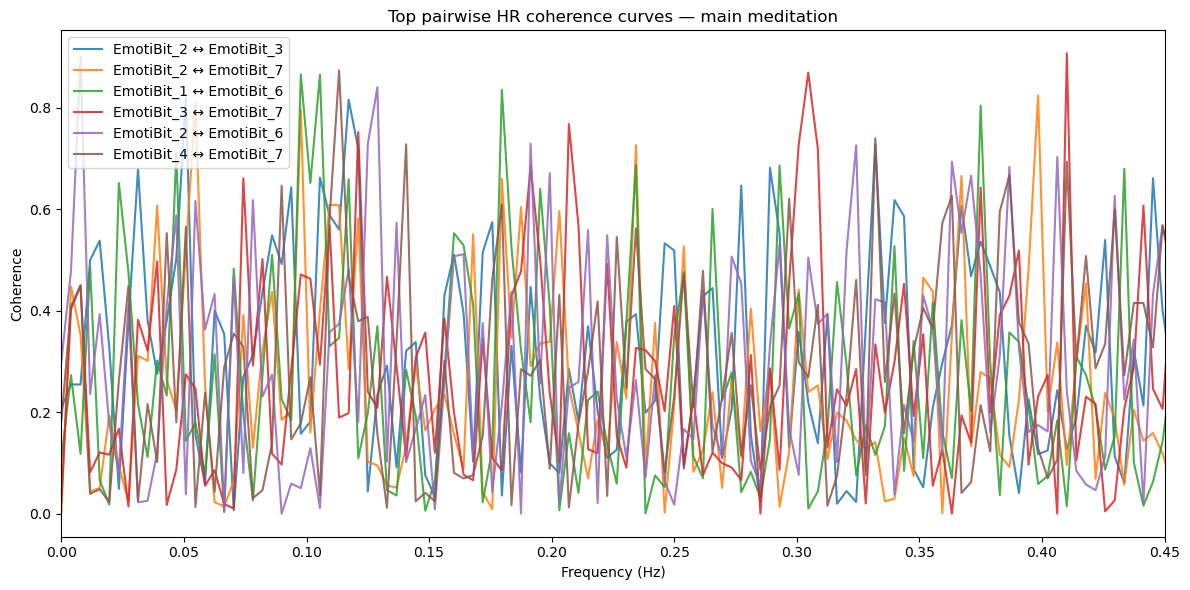

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_top_pairwise_coherence_main_meditation.png


In [15]:
top_n = 6
top_pairs = main_coh_ranked.head(top_n)[["subject_a", "subject_b"]].values.tolist()

plt.figure(figsize=(12, 6))

for a, b in top_pairs:
    freqs, coh = coh_curves.get(("main_meditation", a, b), (None, None))
    if freqs is None or len(freqs) == 0:
        continue
    plt.plot(freqs, coh, label=f"{a} ↔ {b}", alpha=0.85)

plt.xlim(0, 0.45)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Coherence")
plt.title("Top pairwise HR coherence curves — main meditation")
plt.legend()
plt.tight_layout()

out_path = FIGURES_DIR / "frequency_top_pairwise_coherence_main_meditation.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [16]:
summary_rows = []

for segment in SEGMENTS:
    sub = coh_summary[coh_summary["segment"] == segment].copy()
    if len(sub) == 0:
        continue

    cluster_sub = sub[
        sub["subject_a"].isin(CANDIDATE_CLUSTER) &
        sub["subject_b"].isin(CANDIDATE_CLUSTER)
    ].copy()

    row = {"segment": segment}

    for band_name in FREQ_BANDS.keys():
        row[f"whole_{band_name}_coh_mean"] = sub[f"{band_name}_coh_mean"].mean()
        row[f"cluster467_{band_name}_coh_mean"] = cluster_sub[f"{band_name}_coh_mean"].mean()

    summary_rows.append(row)

coh_band_summary = pd.DataFrame(summary_rows)
display(coh_band_summary)

,segment,whole_vlf_like_0p01_0p05_coh_mean,cluster467_vlf_like_0p01_0p05_coh_mean,whole_lf_0p05_0p15_coh_mean,cluster467_lf_0p05_0p15_coh_mean,whole_hf_0p15_0p40_coh_mean,cluster467_hf_0p15_0p40_coh_mean
0,pre_meditation,0.485896,0.450859,0.495655,0.573339,0.498018,0.471303
1,main_meditation,0.228893,0.208993,0.260786,0.247670,0.270703,0.282349
2,recovery,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
out_path = TABLES_DIR / "frequency_coherence_band_summary.csv"
coh_band_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/frequency_coherence_band_summary.csv


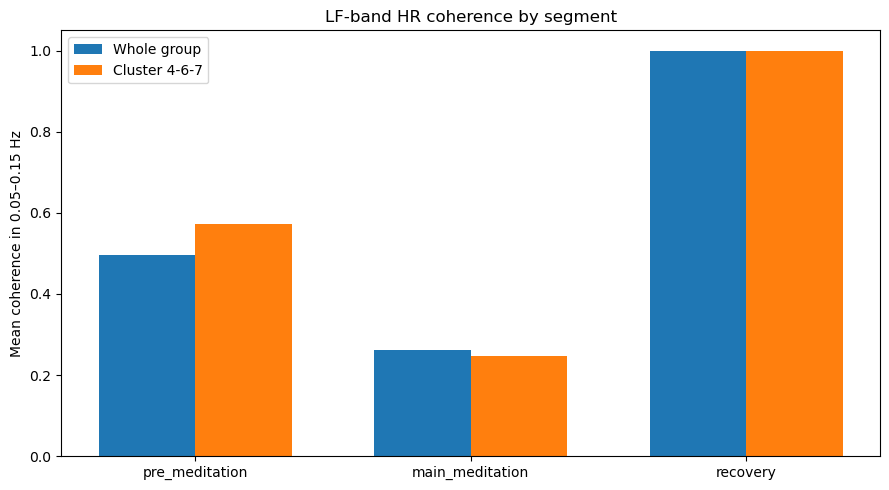

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_lf_band_coherence_by_segment.png


In [18]:
plot_df = coh_band_summary.copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["whole_lf_0p05_0p15_coh_mean"], width, label="Whole group")
plt.bar(x + width/2, plot_df["cluster467_lf_0p05_0p15_coh_mean"], width, label="Cluster 4-6-7")

plt.xticks(x, plot_df["segment"])
plt.ylabel("Mean coherence in 0.05–0.15 Hz")
plt.title("LF-band HR coherence by segment")
plt.legend()
plt.tight_layout()

out_path = FIGURES_DIR / "frequency_lf_band_coherence_by_segment.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

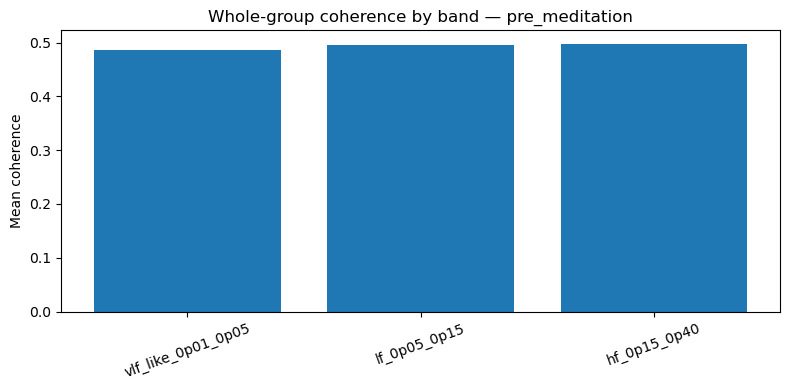

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_whole_group_band_summary_pre_meditation.png


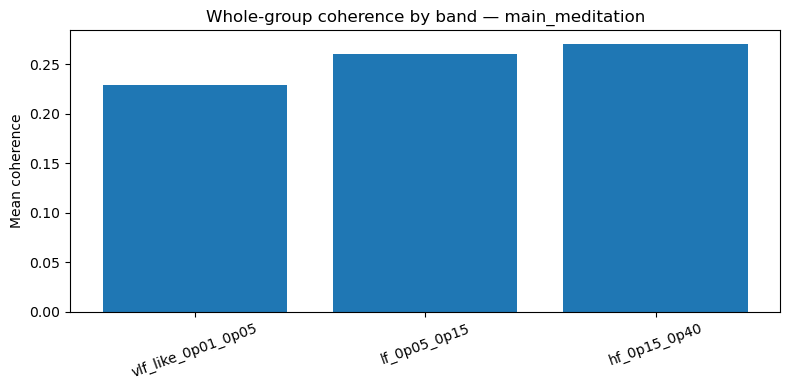

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_whole_group_band_summary_main_meditation.png


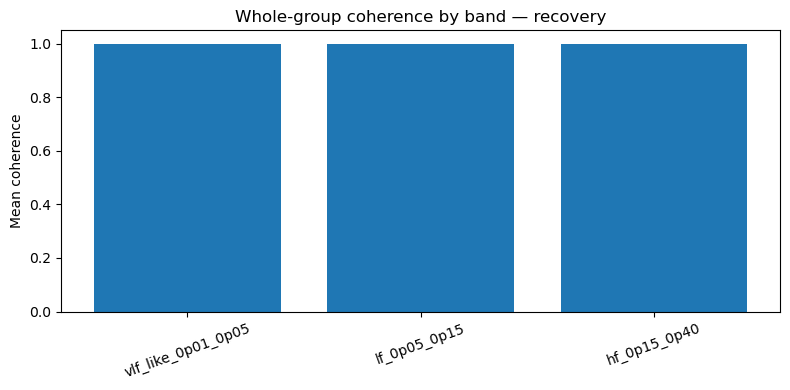

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_whole_group_band_summary_recovery.png


In [19]:
bands = list(FREQ_BANDS.keys())
plot_df = coh_band_summary.copy()

for idx, row in plot_df.iterrows():
    vals = [row[f"whole_{b}_coh_mean"] for b in bands]

    plt.figure(figsize=(8, 4))
    plt.bar(bands, vals)
    plt.ylabel("Mean coherence")
    plt.title(f"Whole-group coherence by band — {row['segment']}")
    plt.xticks(rotation=20)
    plt.tight_layout()

    out_path = FIGURES_DIR / f"frequency_whole_group_band_summary_{row['segment']}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

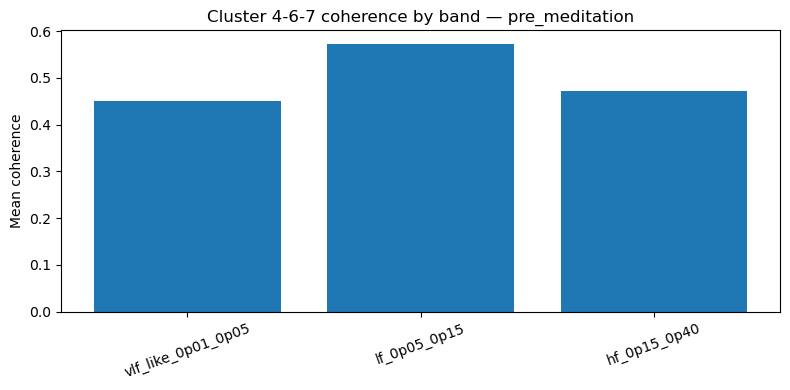

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_cluster467_band_summary_pre_meditation.png


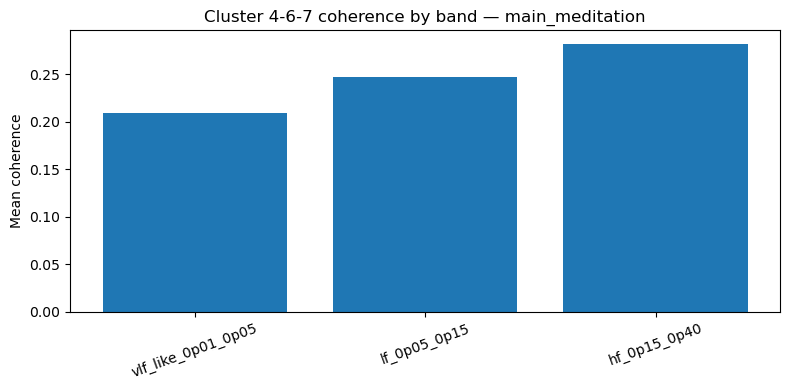

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_cluster467_band_summary_main_meditation.png


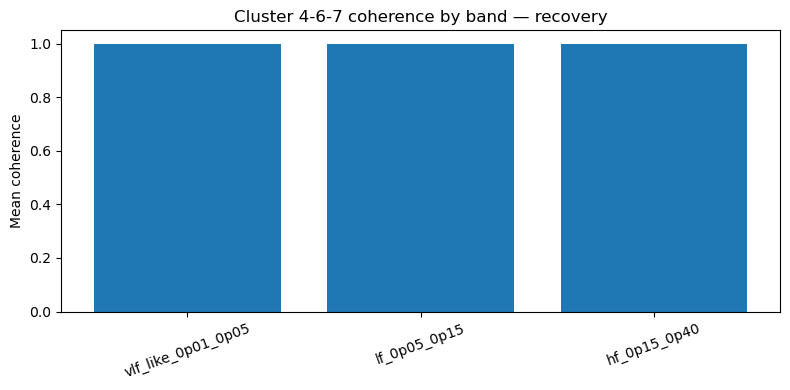

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/frequency_cluster467_band_summary_recovery.png


In [20]:
bands = list(FREQ_BANDS.keys())
plot_df = coh_band_summary.copy()

for idx, row in plot_df.iterrows():
    vals = [row[f"cluster467_{b}_coh_mean"] for b in bands]

    plt.figure(figsize=(8, 4))
    plt.bar(bands, vals)
    plt.ylabel("Mean coherence")
    plt.title(f"Cluster 4-6-7 coherence by band — {row['segment']}")
    plt.xticks(rotation=20)
    plt.tight_layout()

    out_path = FIGURES_DIR / f"frequency_cluster467_band_summary_{row['segment']}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [21]:
lf_table = coh_band_summary[[
    "segment",
    "whole_lf_0p05_0p15_coh_mean",
    "cluster467_lf_0p05_0p15_coh_mean",
]].copy()

lf_table = lf_table.rename(columns={
    "whole_lf_0p05_0p15_coh_mean": "whole_group_lf_coherence",
    "cluster467_lf_0p05_0p15_coh_mean": "cluster467_lf_coherence",
})

display(lf_table)

,segment,whole_group_lf_coherence,cluster467_lf_coherence
0,pre_meditation,0.495655,0.573339
1,main_meditation,0.260786,0.247670
2,recovery,1.000000,1.000000


In [22]:
out_path = TABLES_DIR / "frequency_lf_coherence_comparison.csv"
lf_table.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/frequency_lf_coherence_comparison.csv


In [23]:
print("=== FREQUENCY-DOMAIN EXPLORATION ===")
print("Computed:")
print("1. Welch PSD for aligned HR signals")
print("2. Pairwise magnitude-squared coherence")
print("3. Band summaries for whole group and subgroup 4-6-7")
print()
print("Important:")
print("Treat coherence as exploratory unless it matches the validated time-domain findings.")
print()
print("Reminder for later:")
print("Add a spectrogram / time-frequency figure in a later notebook if needed for professor presentation.")

=== FREQUENCY-DOMAIN EXPLORATION ===
Computed:
1. Welch PSD for aligned HR signals
2. Pairwise magnitude-squared coherence
3. Band summaries for whole group and subgroup 4-6-7

Important:
Treat coherence as exploratory unless it matches the validated time-domain findings.

Reminder for later:
Add a spectrogram / time-frequency figure in a later notebook if needed for professor presentation.
